In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

In [4]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [5]:
# feature scaling
scaler = StandardScaler()
X_train_scaled_full = pd.DataFrame(
    scaler.fit_transform(X_train), columns=wine.feature_names
)
X_test_scaled_full = pd.DataFrame(
    scaler.transform(X_test), columns=wine.feature_names
)

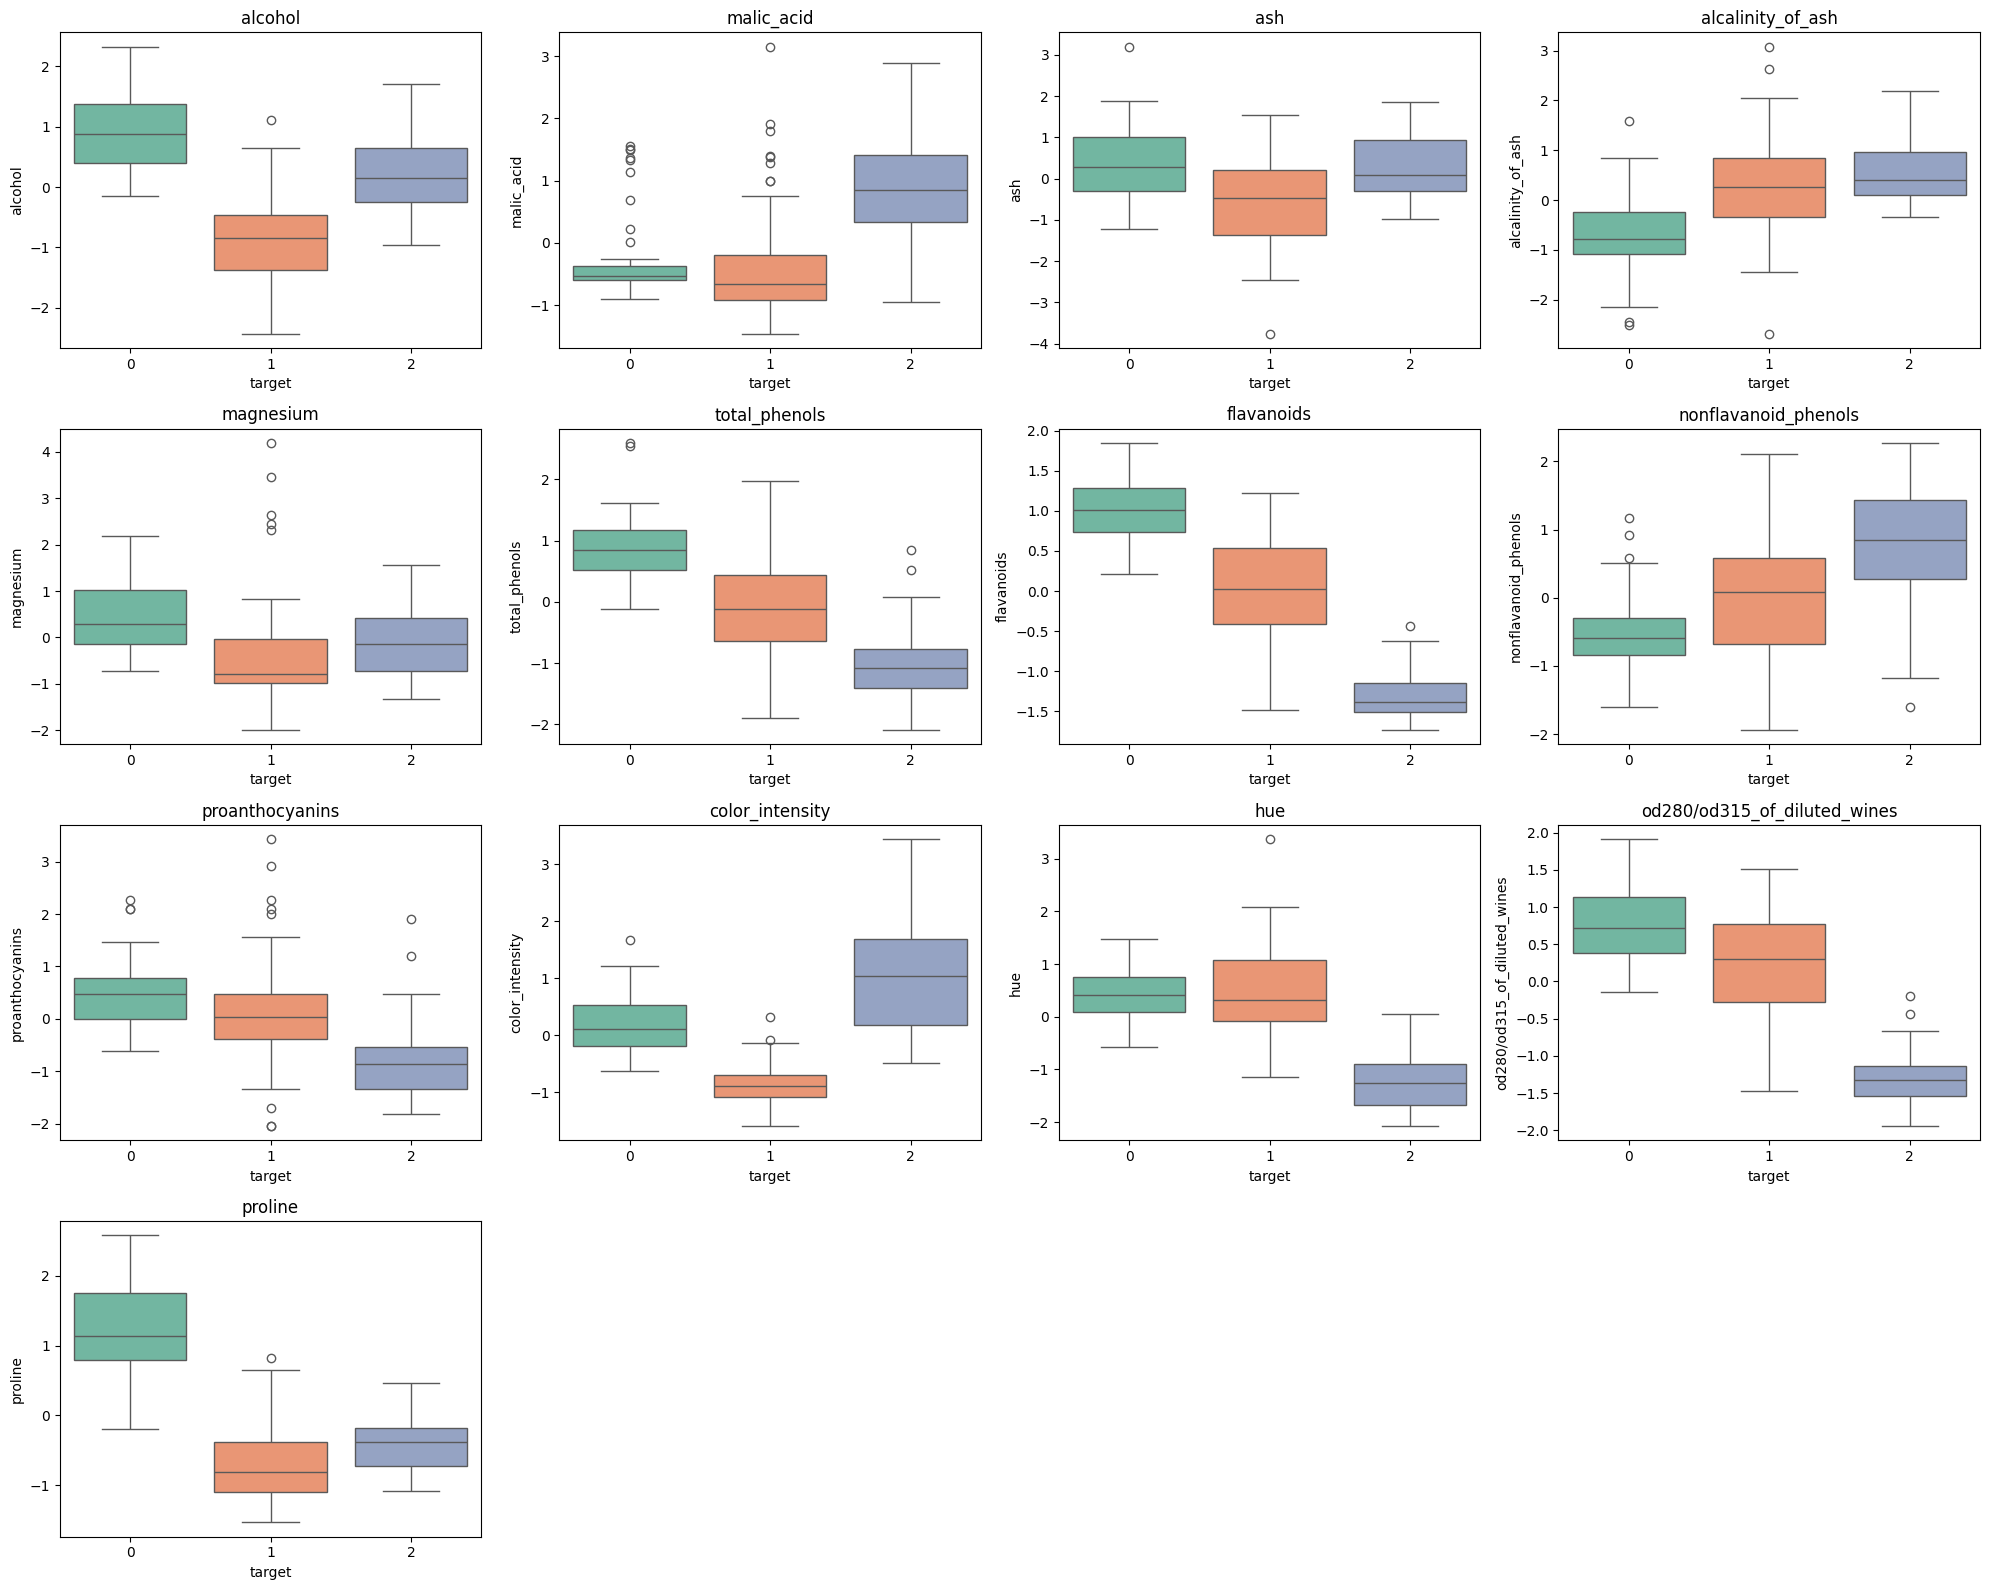

In [6]:
# feature selection 1 (box plots)
train_df = X_train_scaled_full.copy()
train_df["target"] = y_train.values

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(wine.feature_names):
    sns.boxplot(x="target", y=col, data=train_df, ax=axes[i], hue="target", palette="Set2", legend=False)
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.tight_layout()
plt.show()

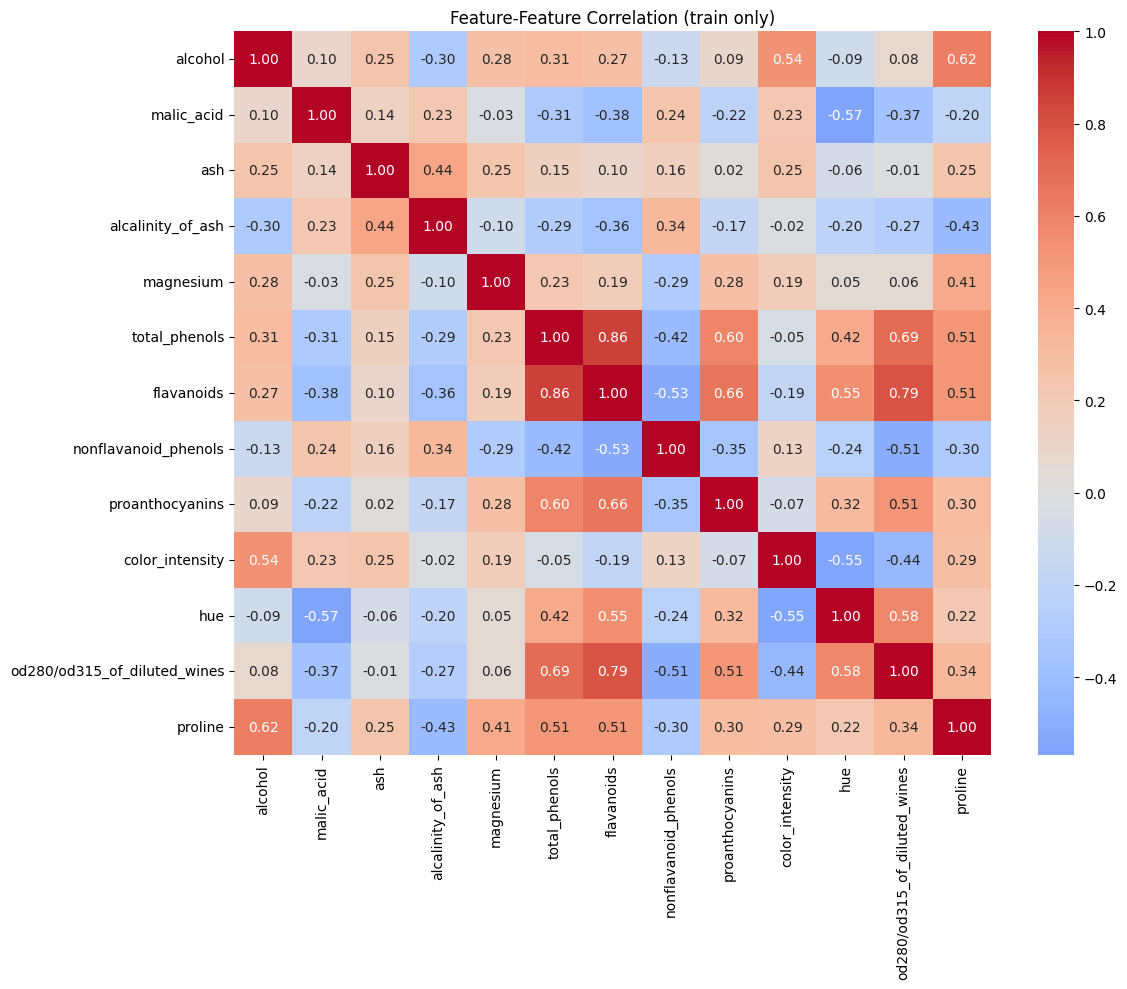

In [7]:
# feature selection 2 (heat map)

plt.figure(figsize=(12, 10))
sns.heatmap(train_df[wine.feature_names].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature-Feature Correlation (train only)")
plt.tight_layout()
plt.show()

### 5-3) FEATURE SELECTION

Box plot shows that the following features are the features that have clear difference between 3 classes (분산 대비 클래스간 차이가 큰 순서): ***flavanoids > proline > od280/od315 > alcohol > color_intensity > hue > total_phenols*** (나머지는 클래스가 많이 겹침)

Heat map shows that ***flavanoids & od280/od315(0.78), flavanoids & total_phenols(0.86) have high correlation***, which means they have overlapping/duplicative information. So, we choose features with highly separable feature (i.e. low correlation)

### **4 good features: alcohol, flavanoids, hue, proline**
- flavanoids, proline, alcohol: seperable features (from box plots)
- hue: okay correlation with flavanoids(0.52), low correlation with alcohol/proline(-0.00, 0.25) (from heat map)

In [12]:
selected_features = ["alcohol", "flavanoids", "hue", "proline"]
print(f"Selected features: {selected_features}")


X_train_scaled = X_train_scaled_full[selected_features].values
X_test_scaled = X_test_scaled_full[selected_features].values

Selected features: ['alcohol', 'flavanoids', 'hue', 'proline']


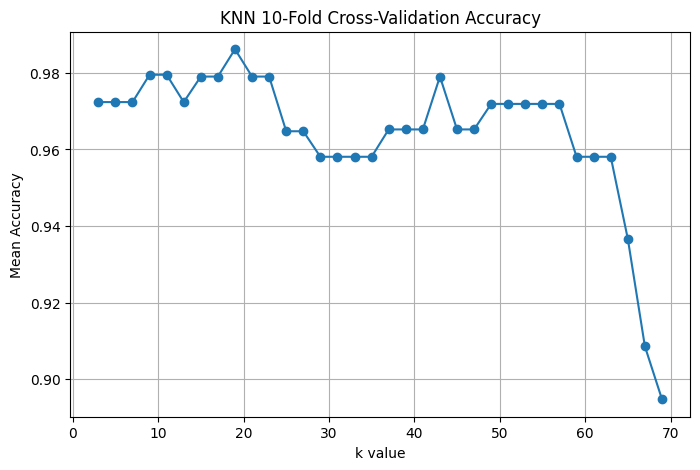

In [16]:
# cross validation
max_k = len(X_train_scaled) // 2
k_list = list(range(3, max_k, 2))

cross_validation_scores = []
all_scores = {}

kf = KFold(n_splits=10, shuffle=True, random_state=35)

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=kf, scoring="accuracy")
    cross_validation_scores.append(scores.mean())
    all_scores[k] = scores

plt.figure(figsize=(8, 5))
plt.plot(k_list, cross_validation_scores, marker="o")
plt.xlabel("k value")
plt.ylabel("Mean Accuracy")
plt.title("KNN 10-Fold Cross-Validation Accuracy")
plt.grid(True)
plt.show()

In [17]:
# 7) SELECT BEST K & TRAIN FINAL MODEL
best_k_index = np.argmax(cross_validation_scores)
best_k = k_list[best_k_index]
print(f"Best k from CV: {best_k}")

final_knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
final_knn.fit(X_train_scaled, y_train)

Best k from CV: 19


KNeighborsClassifier(metric='euclidean', n_neighbors=19)

In [18]:
# 8) EVALUATE ON TEST SET
y_pred = final_knn.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test-set Accuracy: {test_acc:.3f}")

Test-set Accuracy: 1.000
